In [1]:
import requests
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from utils import plot_spikes

## File paths

In [3]:
base_url = "https://gin.g-node.org/NeuroGroup_TUNI/Comparative_MEA_dataset/raw/master/Data/hPSC_MEA3_Pharmacology/"

### Baseline

In [ ]:
baseline_url = "hPSC_MEA3Baseline_DIV29/hPSC_MEA3Baseline_DIV29_spikes_noise_explogs/"
spikes_csv_url = baseline_url + "hPSC_120618_MEA3Baseline_DIV29_spikes.csv"
noisy_channels_csv_url = baseline_url + "noisy_electrodes_hPSC_MEA3Baseline_DIV29.csv"
filename = "spikes_recording_baseline.csv"
output_filename = "spikes_baseline_processed"

### Treatment

**Uncomment this part to do exacly the same process as the baseline, but for the treatment group.**

In [5]:
# treatment_url = "hPSC_MEA3Pharma_DIV29/hPSC_MEA3Pharma_DIV29_spikes_noise_explogs/"
# spikes_csv_url = treatment_url + "hPSC_120618_MEA3Pharma_DIV29_spikes.csv"
# noisy_channels_csv_url = treatment_url + "noisy_electrodes_hPSC_MEA3Pharma_DIV29.csv"
# filename = "spikes_recording_treatment.csv"
# output_filename = "spikes_treatment_processed"

## Download Spikes Data

In [6]:
datadir = Path("./data/")
datadir.mkdir(exist_ok=True)

filepath = datadir / filename

csv_url = base_url + spikes_csv_url
response = requests.get(csv_url, headers={"Content-type": "text/csv"})

if response.status_code == 200:
    with open(filepath, 'wb') as file:
         file.write(response.content)

    print(f"CSV file downloaded and saved as {filepath}")
else:
    print(f"Failed to download the CSV file. Status code: {response.status_code}")

CSV file downloaded and saved as data/spikes_recording_baseline.csv


## Load Data

In [7]:
spikes_recording_orig = pd.read_csv(f"./data/{filename}")
spikes_recording_orig

,Channel,Time
0,E8_33,0.00152
1,C8_34,0.00160
2,B5_24,0.00184
3,C8_43,0.00200
4,F6_14,0.00240
...,...,...
3270729,D5_44,1799.99680
3270730,B6_12,1799.99712
3270731,E7_23,1799.99792
3270732,F5_21,1799.99792


## Preprocess Data

In [8]:
# group by channel and aggregate time into a list
spikes_recording = spikes_recording_orig.groupby("Channel")["Time"].apply(list).reset_index()
spikes_recording

,Channel,Time
0,A5_11,"[0.13936, 0.46488, 0.7532, 0.97168, 1.2196, 1...."
1,A5_12,"[0.30912, 1.05888, 1.46736, 2.16472, 2.9056, 2..."
2,A5_13,"[0.24208, 0.33024, 0.68032, 1.44944, 3.71648, ..."
3,A5_14,"[0.42488, 1.37192, 1.40024, 1.62248, 1.7092, 1..."
4,A5_21,"[0.64, 0.73336, 1.32408, 1.6256, 2.45096, 2.62..."
...,...,...
379,F8_34,"[1.40888, 1.95128, 2.24448, 2.58248, 2.61496, ..."
380,F8_41,"[0.41984, 0.47576, 0.5532, 1.60848, 2.23488, 2..."
381,F8_42,"[0.92936, 2.122, 2.24208, 2.30432, 3.20448, 3...."
382,F8_43,"[10.2164, 12.16048, 26.43208, 32.93592, 47.397..."


In [9]:
#split Channel column in well and channel
spikes_recording[["well", "channel"]] = spikes_recording["Channel"].str.split("_", expand=True)
spikes_recording["channel"] = spikes_recording["channel"].astype("int64")
print(spikes_recording.dtypes)
spikes_recording

Channel    object
Time       object
well       object
channel     int64
dtype: object


,Channel,Time,well,channel
0,A5_11,"[0.13936, 0.46488, 0.7532, 0.97168, 1.2196, 1....",A5,11
1,A5_12,"[0.30912, 1.05888, 1.46736, 2.16472, 2.9056, 2...",A5,12
2,A5_13,"[0.24208, 0.33024, 0.68032, 1.44944, 3.71648, ...",A5,13
3,A5_14,"[0.42488, 1.37192, 1.40024, 1.62248, 1.7092, 1...",A5,14
4,A5_21,"[0.64, 0.73336, 1.32408, 1.6256, 2.45096, 2.62...",A5,21
...,...,...,...,...
379,F8_34,"[1.40888, 1.95128, 2.24448, 2.58248, 2.61496, ...",F8,34
380,F8_41,"[0.41984, 0.47576, 0.5532, 1.60848, 2.23488, 2...",F8,41
381,F8_42,"[0.92936, 2.122, 2.24208, 2.30432, 3.20448, 3....",F8,42
382,F8_43,"[10.2164, 12.16048, 26.43208, 32.93592, 47.397...",F8,43


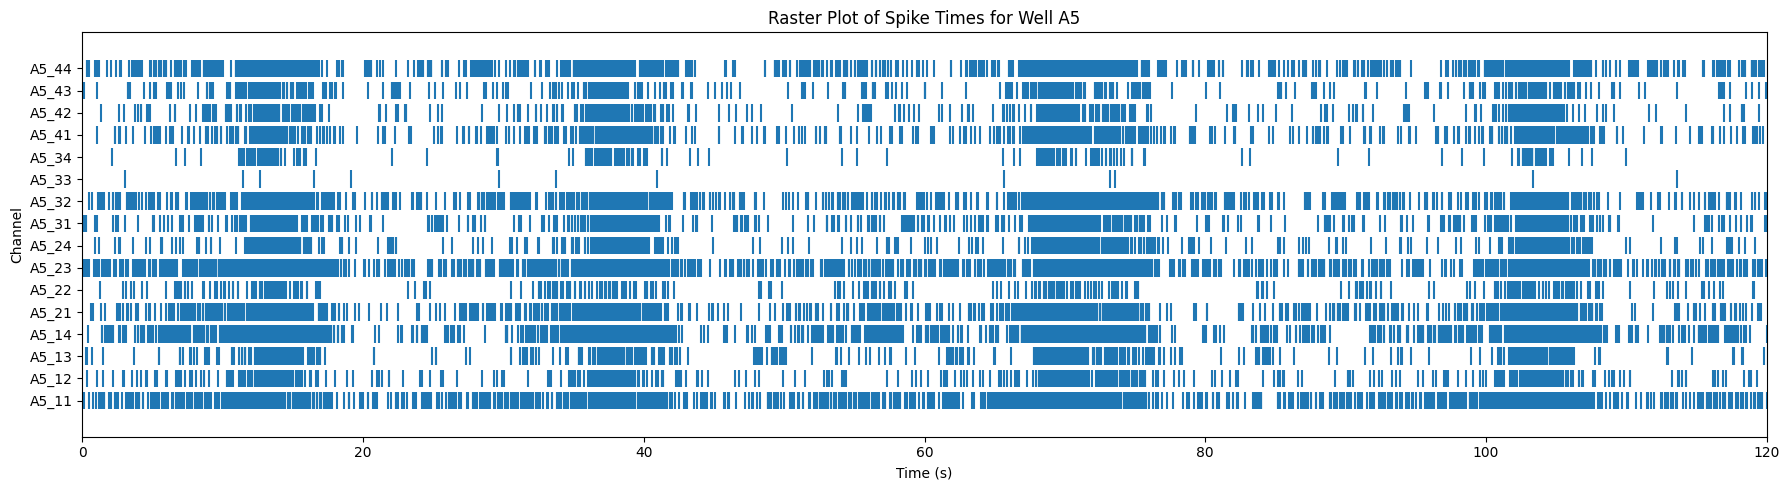

In [10]:
spikes_A5 = spikes_recording[spikes_recording["well"] == "A5"].reset_index(drop=True)
plot_spikes(spikes_A5, duration=120, well="A5")

## Remove inactive and noisy channels

## Loading noisy channels

In [11]:
datadir = Path("./data/")
datadir.mkdir(exist_ok=True)

filename = "noisy_channels.csv"
filepath = datadir / filename

csv_url = base_url + noisy_channels_csv_url
response = requests.get(csv_url, headers={"Content-type": "text/csv"})

if response.status_code == 200:
    with open(filepath, 'wb') as file:
         file.write(response.content)

    print(f"CSV file downloaded and saved as {filepath}")
else:
    print(f"Failed to download the CSV file. Status code: {response.status_code}")

CSV file downloaded and saved as data/noisy_channels.csv


In [12]:
noisy_channels = pd.read_csv("./data/noisy_channels.csv")
noisy_channels

,DIV29
0,A4_21
1,F6_43
2,F2_31


In [13]:
noisy_channels_list = noisy_channels["DIV29"].tolist()
noisy_channels_list

['A4_21', 'F6_43', 'F2_31']

## Finding inactive channels

In [14]:
spikes_recording["spike_count"] = spikes_recording["Time"].apply(len)
spikes_recording

,Channel,Time,well,channel,spike_count
0,A5_11,"[0.13936, 0.46488, 0.7532, 0.97168, 1.2196, 1....",A5,11,19572
1,A5_12,"[0.30912, 1.05888, 1.46736, 2.16472, 2.9056, 2...",A5,12,9228
2,A5_13,"[0.24208, 0.33024, 0.68032, 1.44944, 3.71648, ...",A5,13,5365
3,A5_14,"[0.42488, 1.37192, 1.40024, 1.62248, 1.7092, 1...",A5,14,23267
4,A5_21,"[0.64, 0.73336, 1.32408, 1.6256, 2.45096, 2.62...",A5,21,11932
...,...,...,...,...,...
379,F8_34,"[1.40888, 1.95128, 2.24448, 2.58248, 2.61496, ...",F8,34,9202
380,F8_41,"[0.41984, 0.47576, 0.5532, 1.60848, 2.23488, 2...",F8,41,1691
381,F8_42,"[0.92936, 2.122, 2.24208, 2.30432, 3.20448, 3....",F8,42,7138
382,F8_43,"[10.2164, 12.16048, 26.43208, 32.93592, 47.397...",F8,43,309


## Cleaning the recording data

In [15]:
mask = (spikes_recording["spike_count"] > 300) & (~spikes_recording["Channel"].isin(noisy_channels_list))
spikes_recording_clean = spikes_recording[mask]
spikes_recording_clean


,Channel,Time,well,channel,spike_count
0,A5_11,"[0.13936, 0.46488, 0.7532, 0.97168, 1.2196, 1....",A5,11,19572
1,A5_12,"[0.30912, 1.05888, 1.46736, 2.16472, 2.9056, 2...",A5,12,9228
2,A5_13,"[0.24208, 0.33024, 0.68032, 1.44944, 3.71648, ...",A5,13,5365
3,A5_14,"[0.42488, 1.37192, 1.40024, 1.62248, 1.7092, 1...",A5,14,23267
4,A5_21,"[0.64, 0.73336, 1.32408, 1.6256, 2.45096, 2.62...",A5,21,11932
...,...,...,...,...,...
379,F8_34,"[1.40888, 1.95128, 2.24448, 2.58248, 2.61496, ...",F8,34,9202
380,F8_41,"[0.41984, 0.47576, 0.5532, 1.60848, 2.23488, 2...",F8,41,1691
381,F8_42,"[0.92936, 2.122, 2.24208, 2.30432, 3.20448, 3....",F8,42,7138
382,F8_43,"[10.2164, 12.16048, 26.43208, 32.93592, 47.397...",F8,43,309


In [16]:
# save cleaned recording to csv
spikes_recording_clean.to_pickle(f"./data/{output_filename}.pkl")

In [17]:
spikes_recording_clean = pd.read_pickle(f"./data/{output_filename}.pkl")

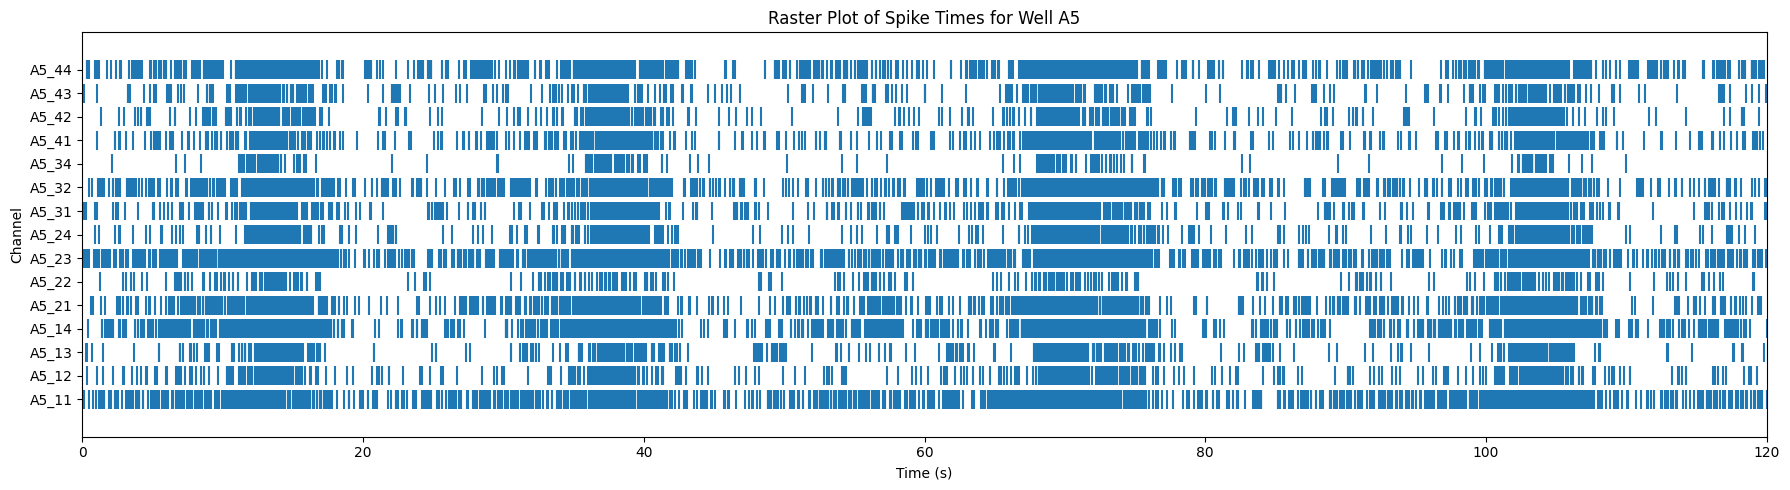

In [18]:
spikes_A5 = spikes_recording_clean[spikes_recording_clean["well"] == "A5"].reset_index(drop=True)
plot_spikes(spikes_A5, duration=120, well="A5")